# Homework 1

**Dataset:** Les Misérables character co-appearance network (NetworkX built-in). Nodes are characters from the novel, two characters are connected if the appear in the same chapter, with a **weight** equal to the number of co-appearances.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.les_miserables_graph()

print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

sample = list(G.nodes(data=True))[:8]
for node, attrs in sample:
    print(node, attrs)

e = list(G.edges(data=True))[0]
print("\nExample edge (u, v, weight):", e)

Number of nodes: 77
Number of edges: 254
Napoleon {}
Myriel {}
MlleBaptistine {}
MmeMagloire {}
CountessDeLo {}
Geborand {}
Champtercier {}
Cravatte {}

Example edge (u, v, weight): ('Napoleon', 'Myriel', {'weight': 1})


## 1. Draw the full graph with labels

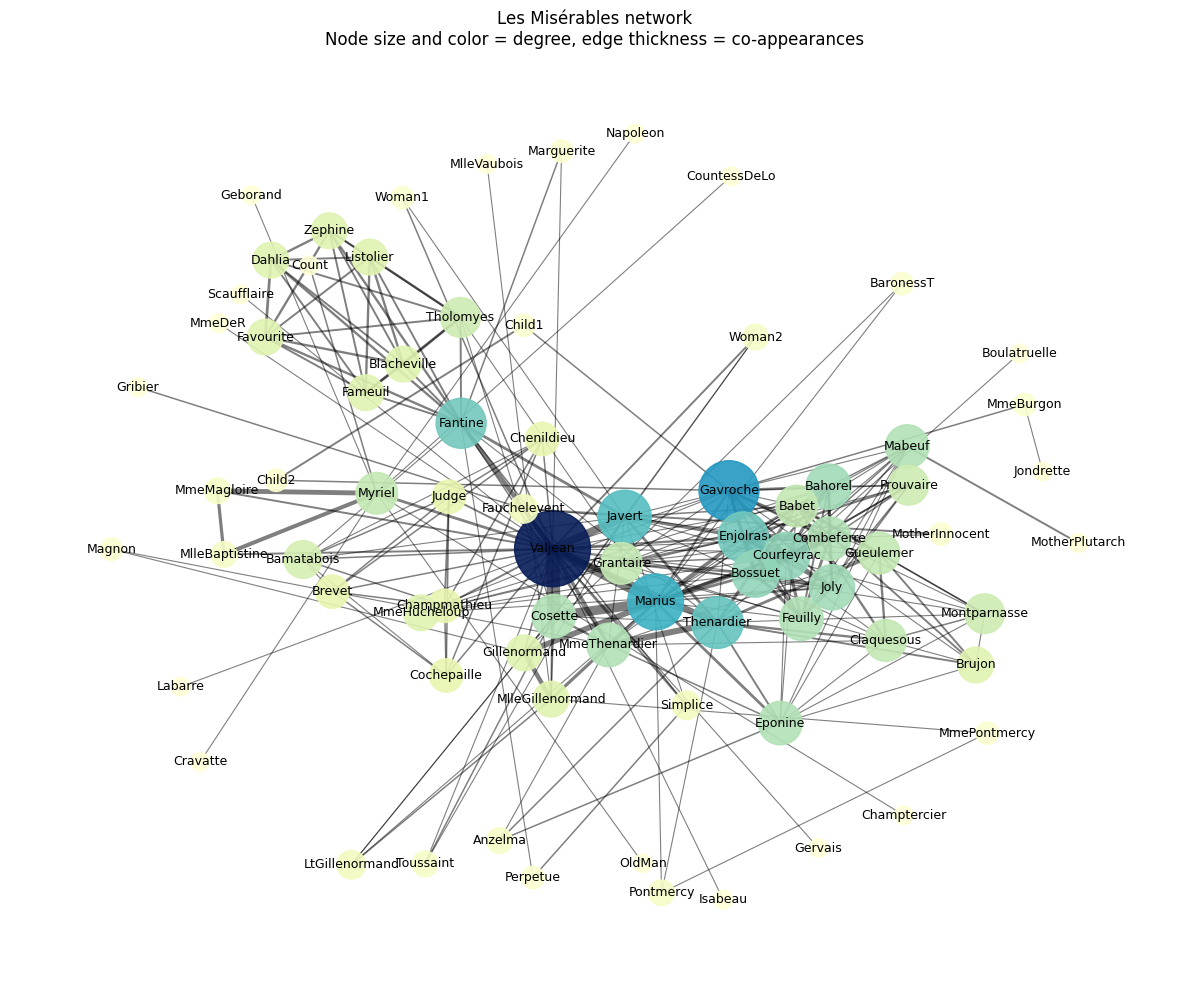

In [2]:
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, seed=42, k=1.0)

degrees = dict(G.degree())
node_sizes = [100 + 80 * degrees[n] for n in G.nodes()]
# Color by degree (more connections = darker)
node_colors = [degrees[n] for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, cmap="YlGnBu", alpha=0.9)
# Edge width from weight (co-appearance count); default weight 1 if missing
widths = [G.edges[u, v].get("weight", 1) for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, width=[0.5 + 0.3 * w for w in widths], alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=9)

plt.title("Les Misérables network\nNode size and color = degree, edge thickness = co-appearances")
plt.axis("off")
plt.tight_layout()
plt.show()

## 2. Show top nodes, i.e. main characters in the novel

Top characters by degree centrality (most co-appearances):
  Valjean: 0.474
  Gavroche: 0.289
  Marius: 0.250
  Javert: 0.224
  Thenardier: 0.211
  Fantine: 0.197
  Enjolras: 0.197
  Courfeyrac: 0.171
  Bossuet: 0.171
  Bahorel: 0.158
  Joly: 0.158
  MmeThenardier: 0.145


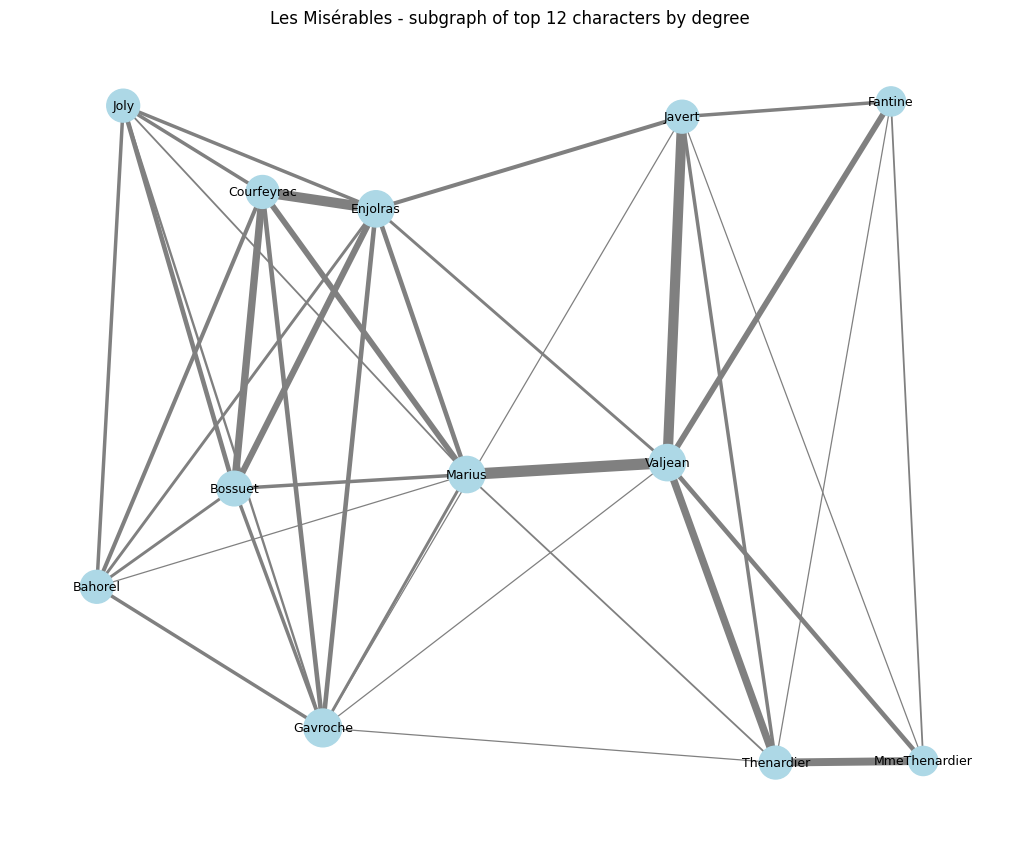

In [3]:
k = 12
degree_centrality = nx.degree_centrality(G)
central_nodes = sorted(degree_centrality, key=degree_centrality.get, reverse=True)[:k]
print("Top characters by degree centrality (most co-appearances):")
for n in central_nodes:
    print(f"  {n}: {degree_centrality[n]:.3f}")

H = G.subgraph(central_nodes).copy()
plt.figure(figsize=(10, 8))
sub_pos = nx.spring_layout(H, seed=0, k=0.6)
sub_degrees = dict(H.degree())
sub_sizes = [200 + 60 * sub_degrees[n] for n in H.nodes()]
edge_w = [H.edges[u, v].get("weight", 1) for u, v in H.edges()]
nx.draw(H, sub_pos, with_labels=True, node_size=sub_sizes, node_color="lightblue",
        edge_color="gray", width=[0.5 + 0.4 * w for w in edge_w], font_size=9)
plt.title("Les Misérables - subgraph of top 12 characters by degree")
plt.axis("off")
plt.show()

## 3. Simple algorithms

In [4]:
source, target = "Cravatte", "Eponine"
shortest_path = nx.shortest_path(G, source=source, target=target)

print(f"Shortest path from {source} to {target}:")
print(" - ".join(shortest_path))
print(f"Path length: {len(shortest_path) - 1} steps")


Shortest path from Cravatte to Eponine:
Cravatte - Myriel - Valjean - MmeThenardier - Eponine
Path length: 4 steps


In [5]:
deg_c = nx.degree_centrality(G)
bet_c = nx.betweenness_centrality(G)
clo_c = nx.closeness_centrality(G)

def top_k(centrality_dict, k=5):
    return sorted(centrality_dict.items(), key=lambda x: x[1], reverse=True)[:k]

print("\nTop 5 by degree centrality")
for n, v in top_k(deg_c):
    print(f"  {n}: {v:.3f}")

print("\nTop 5 by betweenness")
for n, v in top_k(bet_c):
    print(f"  {n}: {v:.3f}")

print("\nTop 5 by closeness")
for n, v in top_k(clo_c):
    print(f"  {n}: {v:.3f}")



Top 5 by degree centrality
  Valjean: 0.474
  Gavroche: 0.289
  Marius: 0.250
  Javert: 0.224
  Thenardier: 0.211

Top 5 by betweenness
  Valjean: 0.570
  Myriel: 0.177
  Gavroche: 0.165
  Marius: 0.132
  Fantine: 0.130

Top 5 by closeness
  Valjean: 0.644
  Marius: 0.531
  Thenardier: 0.517
  Javert: 0.517
  Gavroche: 0.514


In [6]:
clustering = nx.clustering(G)
avg_clustering = sum(clustering.values()) / len(clustering)
print(f"\nAverage clustering coefficient: {avg_clustering:.3f}")


Average clustering coefficient: 0.573


In [7]:
high_clust = top_k(clustering, k=5)
print("Highest local clustering")
for n, v in high_clust:
    print(f"  {n}: {v:.3f}")

Highest local clustering
  MlleBaptistine: 1.000
  MmeMagloire: 1.000
  Marguerite: 1.000
  Listolier: 1.000
  Fameuil: 1.000
